In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
import pandas as pd

In [58]:
file_path = "/content/drive/My Drive/PTDLKD/BT8_522092301_amazon_stock_price.csv"
df = pd.read_csv(file_path)
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2019-09-23,88.849998,89.635002,88.365997,89.264999,89.264999,58446000
1,2019-09-24,89.530502,89.785500,86.777496,87.080498,87.080498,92320000
2,2019-09-25,87.367996,88.650002,86.150002,88.416496,88.416496,69864000
3,2019-09-26,88.139503,88.168503,86.574997,86.991997,86.991997,70736000
4,2019-09-27,87.400002,87.456001,85.691002,86.272499,86.272499,78144000


Phân tích cột 'Date' dưới dạng datetime, chọn cột Close làm biến dự báo


In [59]:
df['Date'] = pd.to_datetime(df['Date'])

close_data = df['Close']

print(close_data.head())

0    89.264999
1    87.080498
2    88.416496
3    86.991997
4    86.272499
Name: Close, dtype: float64


In [ ]:
!pip uninstall -y pmdarima
!pip uninstall -y numpy


Found existing installation: pmdarima 2.0.4
Uninstalling pmdarima-2.0.4:
  Successfully uninstalled pmdarima-2.0.4
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2


In [3]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 17.3 MB/s eta 0:00:00


In [1]:
!pip install numpy==1.24.4

In [60]:
from pmdarima import auto_arima

# Tự động tìm tham số ARIMA tốt nhất
arima_model = auto_arima(close_data, seasonal=False, trace=True, suppress_warnings=True,stepwise=True)

# In kết quả mô hình tốt nhất
print(arima_model.summary())


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=10.48 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=5097.669, Time=0.11 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=5099.066, Time=0.20 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=5099.092, Time=0.56 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=5095.842, Time=0.05 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=5098.613, Time=2.68 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 14.112 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1007
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -2546.921
Date:                Wed, 09 Apr 2025   AIC                           5095.842
Time:                        09:29:53   BIC                           5100.755
Sample:                             0   HQIC                          5097.709
                               - 1007                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         9.2589      0.229     40.477      0.000       8.811

In [15]:
!pip install statsmodels


In [61]:
import statsmodels.api as sn

In [62]:
from statsmodels.tsa.arima.model import ARIMA

p, d, q = arima_model.order
arima = sn.tsa.ARIMA(close_data, order=(p, d, q))
arima_fit = arima.fit()


In [63]:
# Dự báo 10 bước
arima_forecast = arima_fit.forecast(steps=10)

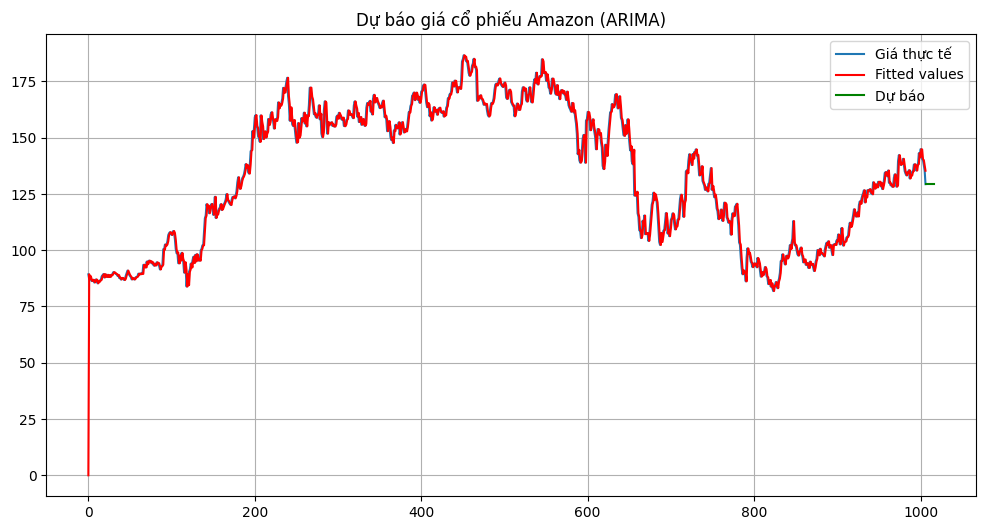

In [65]:
plt.figure(figsize=(12,6))
plt.plot(close_data, label='Giá thực tế')
plt.plot(arima_fit.fittedvalues, color='red', label='Fitted values')
plt.plot(arima_forecast, color='green', label='Dự báo')
plt.title("Dự báo giá cổ phiếu Amazon (ARIMA)")
plt.grid(True)
plt.legend()
plt.show()


ARIMAX

In [66]:
file_path = "/content/drive/My Drive/PTDLKD/BT8_522092301_amazon_stock_price.csv"
df = pd.read_csv(file_path)
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2019-09-23,88.849998,89.635002,88.365997,89.264999,89.264999,58446000
1,2019-09-24,89.530502,89.785500,86.777496,87.080498,87.080498,92320000
2,2019-09-25,87.367996,88.650002,86.150002,88.416496,88.416496,69864000
3,2019-09-26,88.139503,88.168503,86.574997,86.991997,86.991997,70736000
4,2019-09-27,87.400002,87.456001,85.691002,86.272499,86.272499,78144000


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=4.13 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=5097.669, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=5099.066, Time=0.11 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=5099.092, Time=0.26 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=5095.842, Time=0.07 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=5098.613, Time=2.48 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 7.143 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1007
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -2546.921
Date:                Wed, 09 Apr 2025   AIC                           5095.842
Time:                        09:31:17   BIC                           5100.755
Sample:                             0   HQIC                          5097.709
                               - 1007                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         9.2589      0.229     40.477      0.000       8.811 

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Forecast result:  1007    129.331583
1008    129.330670
1009    129.331369
1010    129.330486
1011    129.330309
1012    129.328384
1013    129.331361
1014    129.330436
1015    129.331191
1016    129.330002
Name: predicted_mean, dtype: float64


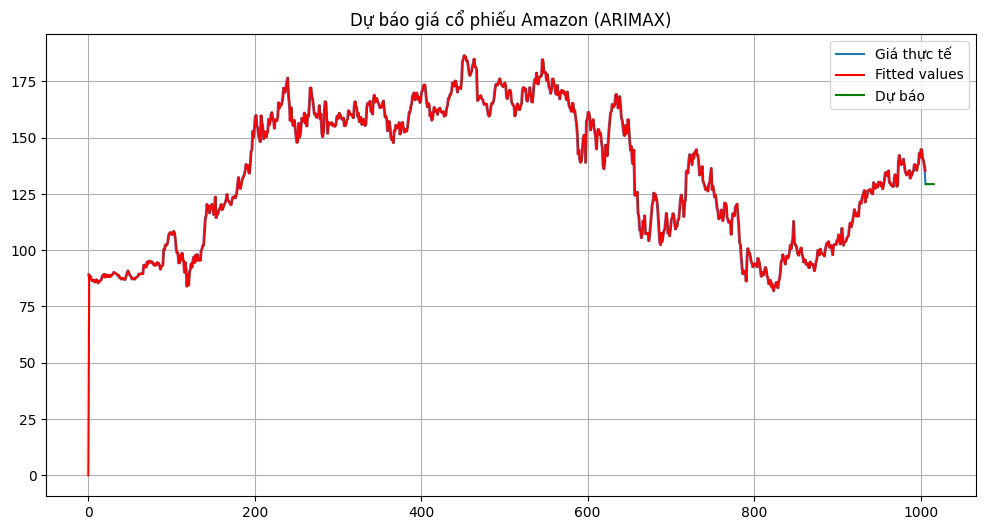

In [67]:
y = df['Close']
X = df['Volume']
# Tự động tìm tham số ARIMA tốt nhất
arima_model = auto_arima(close_data, seasonal=False, trace=True, suppress_warnings=True,stepwise=True)

# In kết quả mô hình tốt nhất
print(arima_model.summary())

p, d, q = arima_model.order
arima = sn.tsa.ARIMA(y,exog=X, order=(p, d, q))
arima_fit = arima.fit()

forecast_steps = 10
arima_forecast = arima_fit.forecast(steps=forecast_steps,exog=X[-forecast_steps:])
print('Forecast result: ', arima_forecast)

plt.figure(figsize=(12,6))
plt.plot(y, label='Giá thực tế')
plt.plot(arima_fit.fittedvalues, color='red', label='Fitted values')
plt.plot(arima_forecast, color='green', label='Dự báo')
plt.title("Dự báo giá cổ phiếu Amazon (ARIMAX)")
plt.grid(True)
plt.legend()
plt.show()


In [70]:
!jupyter nbconvert --to html Nhom15_BTTH8.ipynb


[NbConvertApp] WARNING | pattern 'Nhom15_BTTH8.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
  